# Eigen Analysis

Eigen analysis is a fundamental concept in linear algebra that deals with eigenvalues and eigenvectors of matrices. These concepts are crucial for understanding matrix transformations, dimensionality reduction, and many machine learning algorithms.

## Definition: Characteristic Equation

For a real, symmetric matrix $\mathbf{M} \in \mathbb{R}^{d \times d}$ and a vector $\mathbf{q} \in \mathbb{R}^{d}$:

**Characteristic equation of matrix M:**
$$\mathbf{M}\mathbf{q} = \lambda\mathbf{q}$$

or equivalently:
$$(\mathbf{M} - \lambda\mathbf{I})\mathbf{q} = \mathbf{0}$$

For a given matrix $\mathbf{M}$, there can be several vectors $\mathbf{q}$ and several values $\lambda$ for which the property $\mathbf{M}\mathbf{q} = \lambda\mathbf{q}$ satisfies:

- The vectors for which this property satisfies are called **eigenvectors**
- The values of $\lambda$ which satisfy this characteristic equation are called **eigenvalues**

**Important:** For a square symmetric matrix of size $d \times d$, there will be $d$ eigenvalues and $d$ eigenvectors

## Matrix Transformations and Eigenvectors

### What happens when a vector is multiplied with a matrix?
- **The vector gets transformed into a new vector**
  - Direction changes
- The vector may also get scaled (elongated or shortened) in the process

### Special Property of Eigenvectors
For a given square symmetric matrix $\mathbf{M}$, there exist special vectors which **do not change direction** when multiplied by the matrix.

These vectors are called **eigenvectors**.

More formally:
$$\mathbf{M}\mathbf{q} = \lambda\mathbf{q}$$

- $\lambda$ is the **eigenvalue** - indicates the magnitude of the eigenvector
- The vector will **only get scaled but will not change its direction**

In [52]:
import torch
import numpy as np
import matplotlib.pyplot as plt

## Basis and Linear Independence

### Definition: Basis
A set of $d$ vectors $\{\mathbf{q}_1, \mathbf{q}_2, \ldots, \mathbf{q}_d\} \in \mathbb{R}^d$ is called a **basis** if:
- Those vectors are **linearly independent** 
- Every vector $\in \mathbb{R}^d$ can be expressed as a **linear combination** of these basis vectors

### Definition: Linear Independence
A set of $d$ vectors $\mathbf{q}_1, \mathbf{q}_2, \ldots, \mathbf{q}_d$ is **linearly independent** if no vector in the set can be expressed as a linear combination of the remaining $d-1$ vectors.

Mathematically, the only solution to:
$$c_1\mathbf{q}_1 + c_2\mathbf{q}_2 + \cdots + c_d\mathbf{q}_d = \mathbf{0}$$

is $c_1 = c_2 = \cdots = c_d = 0$ (where $c_i$ are scalars).

### Example: Standard Basis in $\mathbb{R}^2$
Consider the space $\mathbb{R}^2$ with vectors:
$$\mathbf{q}_1 = \begin{bmatrix} 1 \\ 0 \end{bmatrix}, \quad \mathbf{q}_2 = \begin{bmatrix} 0 \\ 1 \end{bmatrix}$$

Any vector $\mathbf{z} = \begin{bmatrix} z_1 \\ z_2 \end{bmatrix}$ can be expressed as:
$$\begin{bmatrix} z_1 \\ z_2 \end{bmatrix} = z_1 \begin{bmatrix} 1 \\ 0 \end{bmatrix} + z_2 \begin{bmatrix} 0 \\ 1 \end{bmatrix}$$

These vectors are linearly independent (the only solution to $c_1\mathbf{q}_1 + c_2\mathbf{q}_2 = \mathbf{0}$ is $c_1 = c_2 = 0$).

They are unit vectors in the direction of the coordinate axes, and we can represent all vectors in $\mathbb{R}^2$ as linear combinations of these two vectors.

### Alternative Basis
We could have chosen any 2 linearly independent vectors in $\mathbb{R}^2$ as basis vectors.

For example: $\mathbf{q}_1 = \begin{bmatrix} 4 \\ 2 \end{bmatrix}$ and $\mathbf{q}_2 = \begin{bmatrix} 5 \\ 7 \end{bmatrix}$

Any vector $\mathbf{z} = \begin{bmatrix} z_1 \\ z_2 \end{bmatrix}$ can be expressed as:
$$\mathbf{z} = \lambda_1 \begin{bmatrix} 4 \\ 2 \end{bmatrix} + \lambda_2 \begin{bmatrix} 5 \\ 7 \end{bmatrix}$$

Or in matrix form:
$$\mathbf{z} = \mathbf{Q}\boldsymbol{\lambda}$$

where $\mathbf{Q} = \begin{bmatrix} 4 & 5 \\ 2 & 7 \end{bmatrix}$ and we solve for coefficients $\lambda_1, \lambda_2$ using:
$$z_1 = 4\lambda_1 + 5\lambda_2$$
$$z_2 = 2\lambda_1 + 7\lambda_2$$

### General Vector Expression in Basis
Given a set of linearly independent vectors $\mathbf{q}_1, \mathbf{q}_2, \ldots, \mathbf{q}_d \in \mathbb{R}^d$, any vector $\mathbf{z} \in \mathbb{R}^d$ can be expressed as:
$$\mathbf{z} = \lambda_1\mathbf{q}_1 + \lambda_2\mathbf{q}_2 + \cdots + \lambda_d\mathbf{q}_d$$

In matrix form:
$$\mathbf{z} = \begin{bmatrix} | & | &  & | \\ \mathbf{q}_1 & \mathbf{q}_2 & \cdots & \mathbf{q}_d \\ | & | &  & | \end{bmatrix} \begin{bmatrix} \lambda_1 \\ \lambda_2 \\ \vdots \\ \lambda_d \end{bmatrix} = \mathbf{Q}\boldsymbol{\lambda}$$

## Orthonormal Basis

A basis is **orthonormal** if:
$$\mathbf{q}_i^T\mathbf{q}_i = 1 \quad \text{and} \quad \mathbf{q}_i^T\mathbf{q}_j = 0 \quad \forall i \neq j$$

This means each vector has unit norm (length 1) and is perpendicular to all other vectors.

### Advantage of Orthonormal Basis
For an orthonormal basis $\{\mathbf{q}_1, \mathbf{q}_2, \ldots, \mathbf{q}_d\}$, to find coefficients $\lambda_i$ for any vector $\mathbf{z}$:

$$\mathbf{z} = \lambda_1\mathbf{q}_1 + \lambda_2\mathbf{q}_2 + \cdots + \lambda_d\mathbf{q}_d$$

Simply multiply $\mathbf{q}_i^T$ to both sides:
$$\mathbf{q}_i^T\mathbf{z} = \lambda_1(\mathbf{q}_i^T\mathbf{q}_1) + \lambda_2(\mathbf{q}_i^T\mathbf{q}_2) + \cdots + \lambda_d(\mathbf{q}_i^T\mathbf{q}_d)$$

Due to orthonormality, all terms vanish except the $i$-th term:
$$\mathbf{q}_i^T\mathbf{z} = \lambda_i$$

**An orthonormal basis is the most convenient basis one can hope for!**

## Eigenvectors as a Basis

### Key Theorems

**Theorem 1:** The eigenvectors of a square symmetric matrix $\mathbf{M} \in \mathbb{R}^{d \times d}$ having **distinct eigenvalues are linearly independent**.

This means eigenvectors **can form a basis** for $\mathbb{R}^d$.

**Theorem 2:** The eigenvectors of a square symmetric matrix are **orthonormal**.

Two vectors are orthonormal when they are:
- **Orthogonal**: perpendicular to each other
- **Unit norm**: each vector has length 1

Mathematically: $\mathbf{q}_i^T\mathbf{q}_i = 1$ and $\mathbf{q}_i^T\mathbf{q}_j = 0$ for $i \neq j$

### Important Consequence
Since eigenvectors of symmetric matrices form an **orthonormal basis**, finding coefficients to express any vector in the eigenvector basis is simple and efficient!

## Expressing Vectors in Different Bases

### Example: Standard Basis vs Alternative Basis

In [53]:
# Example 1: Simple 2x2 symmetric matrix
M = torch.tensor([[1.0, 2.0],
                   [2.0, 1.0]], dtype=torch.float32)

print("Matrix M:")
print(M)

# Compute eigenvalues and eigenvectors
eigenvalues, eigenvectors = torch.linalg.eigh(M)

print(f"\nEigenvalues: {eigenvalues}")
print(f"\nEigenvectors:")
print(eigenvectors)

Matrix M:
tensor([[1., 2.],
        [2., 1.]])

Eigenvalues: tensor([-1.,  3.])

Eigenvectors:
tensor([[-0.7071,  0.7071],
        [ 0.7071,  0.7071]])


## Practical Example: Expressing Vectors in Different Bases

### Standard Basis vs Alternative Basis

We can express the same vector in different bases. Let's see how a vector can be represented in both the standard basis and an alternative basis.

In [54]:
print("EXPRESSING VECTORS IN DIFFERENT BASES")
print("="*60)

# Standard Basis in R^2
print("\n1. STANDARD BASIS (Coordinate axes)")
print("-" * 60)
e1 = torch.tensor([1.0, 0.0])
e2 = torch.tensor([0.0, 1.0])

# Any vector in the standard basis
z = torch.tensor([3.0, 5.0])

print(f"Vector z: {z.numpy()}")
print(f"e1 (basis vector 1): {e1.numpy()}")
print(f"e2 (basis vector 2): {e2.numpy()}")
print(f"\nIn standard basis: z = 3*e1 + 5*e2")
print(f"Verification: 3*e1 + 5*e2 = {(3*e1 + 5*e2).numpy()}")

# Alternative Basis
print("\n\n2. ALTERNATIVE BASIS (Non-standard vectors)")
print("-" * 60)
q1 = torch.tensor([4.0, 2.0])
q2 = torch.tensor([5.0, 7.0])

print(f"Alternative basis vectors:")
print(f"q1: {q1.numpy()}")
print(f"q2: {q2.numpy()}")

# Express same vector z in alternative basis
# z = lambda_1 * q1 + lambda_2 * q2
# Solve: Q @ lambda = z where Q = [q1 q2]
Q_alt = torch.column_stack([q1, q2])

# Solve for coefficients
lambda_coeffs = torch.linalg.solve(Q_alt, z)

print(f"\nExpress same vector z = {z.numpy()} in alternative basis:")
print(f"z = {lambda_coeffs[0]:.4f}*q1 + {lambda_coeffs[1]:.4f}*q2")
print(f"\nVerification: {lambda_coeffs[0]:.4f}*q1 + {lambda_coeffs[1]:.4f}*q2 = {(lambda_coeffs[0]*q1 + lambda_coeffs[1]*q2).numpy()}")

print(f"\nKey insight:")
print(f"  - In standard basis: coefficients are (3.0, 5.0)")
print(f"  - In alternative basis: coefficients are ({lambda_coeffs[0]:.4f}, {lambda_coeffs[1]:.4f})")
print(f"  - Same vector, different representations!")

EXPRESSING VECTORS IN DIFFERENT BASES

1. STANDARD BASIS (Coordinate axes)
------------------------------------------------------------
Vector z: [3. 5.]
e1 (basis vector 1): [1. 0.]
e2 (basis vector 2): [0. 1.]

In standard basis: z = 3*e1 + 5*e2
Verification: 3*e1 + 5*e2 = [3. 5.]


2. ALTERNATIVE BASIS (Non-standard vectors)
------------------------------------------------------------
Alternative basis vectors:
q1: [4. 2.]
q2: [5. 7.]

Express same vector z = [3. 5.] in alternative basis:
z = -0.2222*q1 + 0.7778*q2

Verification: -0.2222*q1 + 0.7778*q2 = [3. 5.]

Key insight:
  - In standard basis: coefficients are (3.0, 5.0)
  - In alternative basis: coefficients are (-0.2222, 0.7778)
  - Same vector, different representations!


In [55]:
print("\n\n3. ORTHONORMAL BASIS (Eigenvector basis)")
print("-" * 60)
print("The ADVANTAGE of orthonormal basis:")
print("  - Computing coefficients is SIMPLE")
print("  - No need to solve linear system")
print("  - Just take dot product with each basis vector!")

# Use eigenvectors from previous computation (which are orthonormal)
print(f"\nEigenvectors of M (already computed):")
for i in range(len(eigenvalues)):
    q = eigenvectors[:, i]
    print(f"  q_{i+1}: {q.numpy()}")

# Express z in eigenvector basis
print(f"\nExpress same vector z = {z.numpy()} in orthonormal basis:")
print("Using simple dot products:")

for i in range(len(eigenvalues)):
    q = eigenvectors[:, i]
    coeff = torch.dot(q, z)
    print(f"  λ_{i+1} = q_{i+1}^T · z = {coeff:.4f}")

# Verify
lambda_ortho = torch.tensor([torch.dot(eigenvectors[:, i], z) for i in range(len(eigenvalues))])
z_reconstructed = eigenvectors @ lambda_ortho

print(f"\nVerification: Q @ λ = {z_reconstructed.numpy()}")
print(f"Original z: {z.numpy()}")
print(f"Match: {torch.allclose(z_reconstructed, z)}")

print("\n✓ For orthonormal basis: λ_i = q_i^T · z (just dot products!)")
print("✓ No need for expensive linear system solve")



3. ORTHONORMAL BASIS (Eigenvector basis)
------------------------------------------------------------
The ADVANTAGE of orthonormal basis:
  - Computing coefficients is SIMPLE
  - No need to solve linear system
  - Just take dot product with each basis vector!

Eigenvectors of M (already computed):
  q_1: [-0.70710677  0.70710677]
  q_2: [0.70710677 0.70710677]

Express same vector z = [3. 5.] in orthonormal basis:
Using simple dot products:
  λ_1 = q_1^T · z = 1.4142
  λ_2 = q_2^T · z = 5.6569

Verification: Q @ λ = [2.9999998 5.       ]
Original z: [3. 5.]
Match: True

✓ For orthonormal basis: λ_i = q_i^T · z (just dot products!)
✓ No need for expensive linear system solve


In [56]:
print("\n\n4. CHECKING LINEAR INDEPENDENCE")
print("-" * 60)

def check_linear_independence(basis_matrix, name):
    """Check if columns of matrix are linearly independent"""
    rank = torch.linalg.matrix_rank(basis_matrix)
    n_cols = basis_matrix.shape[1]
    is_independent = rank == n_cols
    print(f"{name}:")
    print(f"  Rank: {rank}, Number of vectors: {n_cols}")
    print(f"  Linearly independent: {is_independent}")
    return is_independent

# Check standard basis
print("Standard Basis [e1, e2]:")
E = torch.column_stack([e1, e2])
check_linear_independence(E, "  Result")

# Check alternative basis
print("\nAlternative Basis [q1, q2]:")
check_linear_independence(Q_alt, "  Result")

# Check orthonormal basis (eigenvectors)
print("\nOrthonormal Basis (Eigenvectors):")
check_linear_independence(eigenvectors, "  Result")



4. CHECKING LINEAR INDEPENDENCE
------------------------------------------------------------
Standard Basis [e1, e2]:
  Result:
  Rank: 2, Number of vectors: 2
  Linearly independent: True

Alternative Basis [q1, q2]:
  Result:
  Rank: 2, Number of vectors: 2
  Linearly independent: True

Orthonormal Basis (Eigenvectors):
  Result:
  Rank: 2, Number of vectors: 2
  Linearly independent: True


tensor(True)

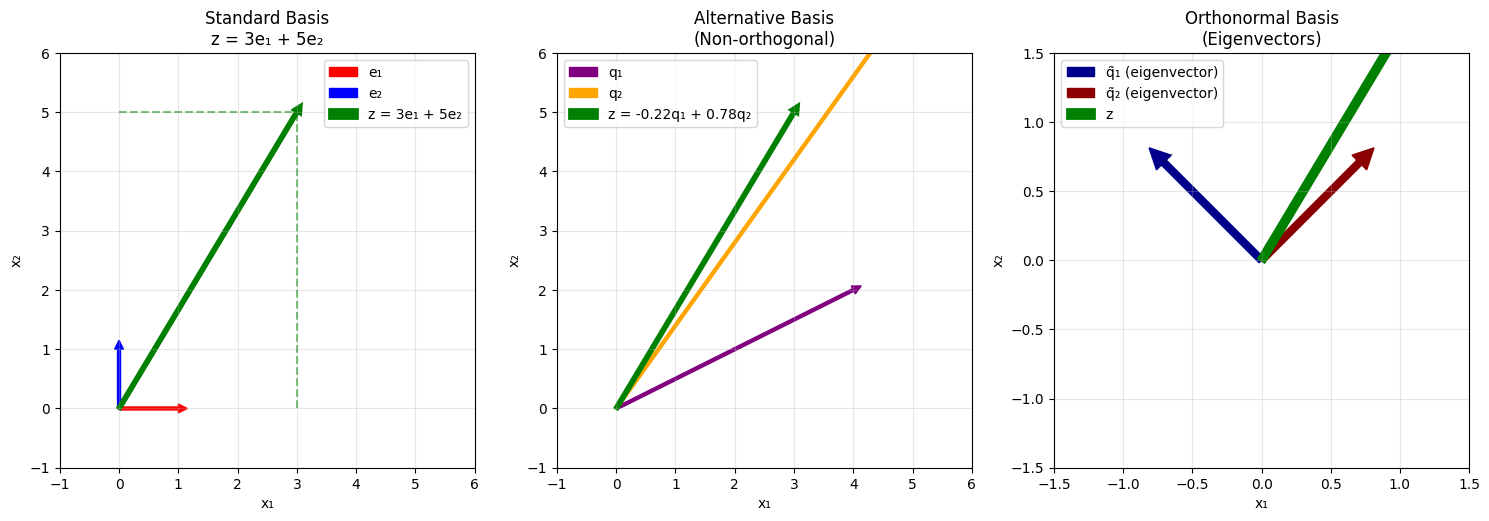


Visualization: Same Vector in Different Bases
- Each plot shows vector z in a different basis
- Standard basis: Uses coordinate axes
- Alternative basis: Uses non-orthogonal vectors (harder to compute coefficients)
- Orthonormal basis: Uses eigenvectors (easy dot product computation)


In [57]:

# Visualization: Different Bases
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Sample point
z_point = z.numpy()

# Plot 1: Standard Basis
ax = axes[0]
e1_np = e1.numpy()
e2_np = e2.numpy()

ax.arrow(0, 0, e1_np[0], e1_np[1], head_width=0.15, head_length=0.15, fc='red', ec='red', width=0.05, label='e₁')
ax.arrow(0, 0, e2_np[0], e2_np[1], head_width=0.15, head_length=0.15, fc='blue', ec='blue', width=0.05, label='e₂')
ax.arrow(0, 0, z_point[0], z_point[1], head_width=0.15, head_length=0.15, fc='green', ec='green', width=0.05, linewidth=2, label='z = 3e₁ + 5e₂')

# Show decomposition
ax.plot([z_point[0], z_point[0]], [0, z_point[1]], 'g--', alpha=0.5)
ax.plot([0, z_point[0]], [z_point[1], z_point[1]], 'g--', alpha=0.5)

ax.set_xlim(-1, 6)
ax.set_ylim(-1, 6)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.set_xlabel('x₁')
ax.set_ylabel('x₂')
ax.set_title('Standard Basis\nz = 3e₁ + 5e₂')
ax.legend()

# Plot 2: Alternative Basis
ax = axes[1]
q1_np = q1.numpy()
q2_np = q2.numpy()

ax.arrow(0, 0, q1_np[0], q1_np[1], head_width=0.15, head_length=0.15, fc='purple', ec='purple', width=0.05, label='q₁')
ax.arrow(0, 0, q2_np[0], q2_np[1], head_width=0.15, head_length=0.15, fc='orange', ec='orange', width=0.05, label='q₂')
ax.arrow(0, 0, z_point[0], z_point[1], head_width=0.15, head_length=0.15, fc='green', ec='green', width=0.05, linewidth=2, label=f'z = {lambda_coeffs[0]:.2f}q₁ + {lambda_coeffs[1]:.2f}q₂')

ax.set_xlim(-1, 6)
ax.set_ylim(-1, 6)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.set_xlabel('x₁')
ax.set_ylabel('x₂')
ax.set_title('Alternative Basis\n(Non-orthogonal)')
ax.legend()

# Plot 3: Orthonormal Basis (Eigenvectors)
ax = axes[2]
eig_vec_1 = eigenvectors[:, 0].numpy()
eig_vec_2 = eigenvectors[:, 1].numpy()

ax.arrow(0, 0, eig_vec_1[0], eig_vec_1[1], head_width=0.15, head_length=0.15, fc='darkblue', ec='darkblue', width=0.05, label='q̃₁ (eigenvector)')
ax.arrow(0, 0, eig_vec_2[0], eig_vec_2[1], head_width=0.15, head_length=0.15, fc='darkred', ec='darkred', width=0.05, label='q̃₂ (eigenvector)')
ax.arrow(0, 0, z_point[0], z_point[1], head_width=0.15, head_length=0.15, fc='green', ec='green', width=0.05, linewidth=2, label='z')

# Draw orthogonality indicator
ax.plot([eig_vec_1[0], eig_vec_1[0]+0.1*eig_vec_2[0]], [eig_vec_1[1], eig_vec_1[1]+0.1*eig_vec_2[1]], 'k--', alpha=0.3, linewidth=1)

ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.set_xlabel('x₁')
ax.set_ylabel('x₂')
ax.set_title('Orthonormal Basis\n(Eigenvectors)')
ax.legend()

plt.tight_layout()
plt.show()

print("\nVisualization: Same Vector in Different Bases")
print("- Each plot shows vector z in a different basis")
print("- Standard basis: Uses coordinate axes")
print("- Alternative basis: Uses non-orthogonal vectors (harder to compute coefficients)")
print("- Orthonormal basis: Uses eigenvectors (easy dot product computation)")

In [58]:
# Verify the eigenvalue equation: M @ q = lambda @ q

print("Verification of Characteristic Equation: M @ q = λ @ q")
print("\n" + "="*50)

for i in range(len(eigenvalues)):
    q = eigenvectors[:, i]  # i-th eigenvector
    lambda_i = eigenvalues[i]  # i-th eigenvalue
    
    # Compute M @ q
    Mq = M @ q
    
    # Compute λ @ q
    lambda_q = lambda_i * q
    
    print(f"\nEigenvector {i+1}: {q.numpy()}")
    print(f"Eigenvalue {i+1}: {lambda_i:.4f}")
    print(f"M @ q: {Mq.numpy()}")
    print(f"λ @ q: {lambda_q.numpy()}")
    print(f"Are they equal? {torch.allclose(Mq, lambda_q)}")

Verification of Characteristic Equation: M @ q = λ @ q


Eigenvector 1: [-0.70710677  0.70710677]
Eigenvalue 1: -1.0000
M @ q: [ 0.70710677 -0.70710677]
λ @ q: [ 0.70710677 -0.70710677]
Are they equal? True

Eigenvector 2: [0.70710677 0.70710677]
Eigenvalue 2: 3.0000
M @ q: [2.1213202 2.1213202]
λ @ q: [2.1213202 2.1213202]
Are they equal? True


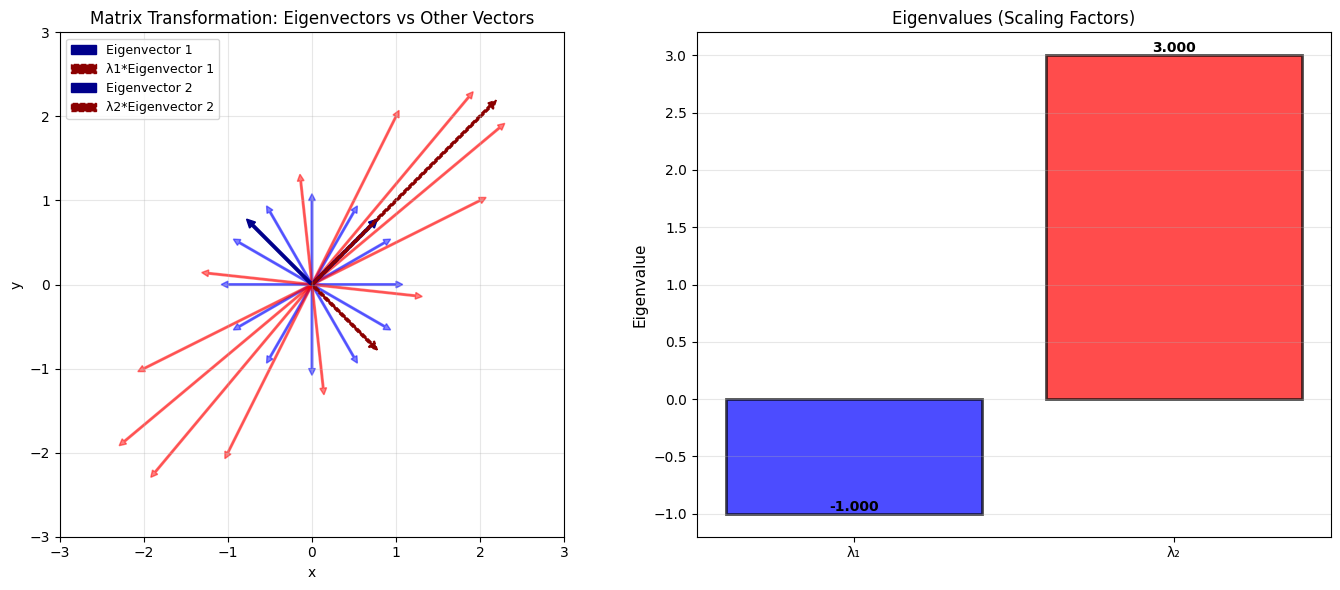

Visualization: Matrix Transformation
- Blue vectors: Original vectors
- Red vectors: Transformed vectors
- Dark blue arrows: Eigenvectors (direction preserved)
- Dark red dashed arrows: Transformed eigenvectors (only scaled)


In [59]:

# Visualization: Matrix Transformation and Eigenvectors
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left plot: Show transformation of various vectors
ax = axes[0]

# Create a grid of vectors
theta = np.linspace(0, 2*np.pi, 12, endpoint=False)
vectors = np.column_stack([np.cos(theta), np.sin(theta)])

# Transform vectors
M_np = M.numpy()
transformed_vectors = (M_np @ vectors.T).T

# Plot original vectors
for v in vectors:
    ax.arrow(0, 0, v[0], v[1], head_width=0.08, head_length=0.08, fc='blue', ec='blue', alpha=0.5, width=0.02)

# Plot transformed vectors
for v in transformed_vectors:
    ax.arrow(0, 0, v[0], v[1], head_width=0.08, head_length=0.08, fc='red', ec='red', alpha=0.5, width=0.02)

# Highlight eigenvectors
for i, (eig_val, eig_vec) in enumerate(zip(eigenvalues, eigenvectors.T)):
    eig_vec_np = eig_vec.numpy()
    eig_val_np = eig_val.item()  # Convert to Python scalar
    # Original eigenvector in blue
    ax.arrow(0, 0, eig_vec_np[0], eig_vec_np[1], head_width=0.1, head_length=0.1, 
             fc='darkblue', ec='darkblue', width=0.03, label=f'Eigenvector {i+1}' if i < 2 else '')
    # Transformed eigenvector (should be on same line, scaled by eigenvalue)
    transformed = eig_val_np * eig_vec_np
    ax.arrow(0, 0, transformed[0], transformed[1], head_width=0.1, head_length=0.1, 
             fc='darkred', ec='darkred', width=0.03, linestyle='--', label=f'λ{i+1}*Eigenvector {i+1}' if i < 2 else '')

ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Matrix Transformation: Eigenvectors vs Other Vectors')
ax.legend(loc='upper left', fontsize=9)

# Right plot: Eigenvalue magnitudes
ax = axes[1]
eigenvalues_np = eigenvalues.numpy()
colors = ['blue', 'red']
bars = ax.bar(range(len(eigenvalues_np)), eigenvalues_np, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax.set_xticks(range(len(eigenvalues_np)))
ax.set_xticklabels([f'λ₁', f'λ₂'])
ax.set_ylabel('Eigenvalue', fontsize=11)
ax.set_title('Eigenvalues (Scaling Factors)')
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, val in zip(bars, eigenvalues_np):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("Visualization: Matrix Transformation")
print("- Blue vectors: Original vectors")
print("- Red vectors: Transformed vectors")
print("- Dark blue arrows: Eigenvectors (direction preserved)")
print("- Dark red dashed arrows: Transformed eigenvectors (only scaled)")

## Properties of Eigenvectors

In [60]:
# Property 1: Eigenvectors are orthonormal (for symmetric matrices)
# Orthonormal: q_i^T @ q_i = 1 and q_i^T @ q_j = 0 for i ≠ j

print("Property 1: Orthonormality of Eigenvectors")
print("="*50)

Q = eigenvectors

# Check orthonormality
print("\nQ^T @ Q (should be identity matrix):")
QtQ = Q.T @ Q
print(QtQ)

# Verify individual vectors are unit norm
print("\nNorms of eigenvectors (should be 1):")
for i in range(len(eigenvalues)):
    norm = torch.linalg.norm(Q[:, i])
    print(f"||q_{i+1}|| = {norm:.4f}")

# Verify orthogonality between different eigenvectors
print("\nDot products between different eigenvectors (should be 0):")
print(f"q_1^T @ q_2 = {torch.dot(Q[:, 0], Q[:, 1]):.6f}")

Property 1: Orthonormality of Eigenvectors

Q^T @ Q (should be identity matrix):
tensor([[1.0000, 0.0000],
        [0.0000, 1.0000]])

Norms of eigenvectors (should be 1):
||q_1|| = 1.0000
||q_2|| = 1.0000

Dot products between different eigenvectors (should be 0):
q_1^T @ q_2 = 0.000000


In [61]:
# Property 2: Eigenvectors can form a basis
# Any vector z in R^d can be expressed as a linear combination of eigenvectors

print("Property 2: Eigenvectors Form a Basis")
print("="*50)

# Create a random vector
z = torch.tensor([3.0, 5.0])

print(f"\nVector z: {z.numpy()}")
print(f"Eigenvectors (basis):")
print(f"q_1: {Q[:, 0].numpy()}")
print(f"q_2: {Q[:, 1].numpy()}")

# Express z as linear combination: z = λ_1 * q_1 + λ_2 * q_2
# Solve Q @ coeffs = z
coeffs = torch.linalg.solve(Q, z)

print(f"\nCoefficients (λ_1, λ_2): {coeffs.numpy()}")

# Verify: Q @ coeffs should equal z
z_reconstructed = Q @ coeffs
print(f"\nReconstruction: Q @ coeffs = {z_reconstructed.numpy()}")
print(f"Original z: {z.numpy()}")
print(f"Match: {torch.allclose(z_reconstructed, z)}")

Property 2: Eigenvectors Form a Basis

Vector z: [3. 5.]
Eigenvectors (basis):
q_1: [-0.70710677  0.70710677]
q_2: [0.70710677 0.70710677]

Coefficients (λ_1, λ_2): [1.4142134 5.656854 ]

Reconstruction: Q @ coeffs = [3.        4.9999995]
Original z: [3. 5.]
Match: True


## Eigenvalues and Matrix Properties

In [62]:
# Property 3: Trace equals sum of eigenvalues
# Theorem: Trace(M) = Σ λ_i

print("Property 3: Trace = Sum of Eigenvalues")
print("="*50)

trace_M = torch.trace(M)
sum_eigenvalues = torch.sum(eigenvalues)

print(f"\nTrace(M) = {trace_M:.4f}")
print(f"Sum of eigenvalues = {sum_eigenvalues:.4f}")
print(f"Match: {torch.allclose(trace_M, sum_eigenvalues)}")

# Show eigenvalues
print(f"\nEigenvalues: {eigenvalues.numpy()}")

Property 3: Trace = Sum of Eigenvalues

Trace(M) = 2.0000
Sum of eigenvalues = 2.0000
Match: True

Eigenvalues: [-1.  3.]


In [63]:
# Property 4: Determinant equals product of eigenvalues
# Theorem: det(M) = ∏ λ_i

print("Property 4: Determinant = Product of Eigenvalues")
print("="*50)

det_M = torch.det(M)
prod_eigenvalues = torch.prod(eigenvalues)

print(f"\ndet(M) = {det_M:.4f}")
print(f"Product of eigenvalues = {prod_eigenvalues:.4f}")
print(f"Match: {torch.allclose(det_M, prod_eigenvalues)}")

# Show eigenvalues
print(f"\nEigenvalues: {eigenvalues.numpy()}")
print(f"Product: {eigenvalues[0]:.4f} × {eigenvalues[1]:.4f} = {prod_eigenvalues:.4f}")

Property 4: Determinant = Product of Eigenvalues

det(M) = -3.0000
Product of eigenvalues = -3.0000
Match: True

Eigenvalues: [-1.  3.]
Product: -1.0000 × 3.0000 = -3.0000


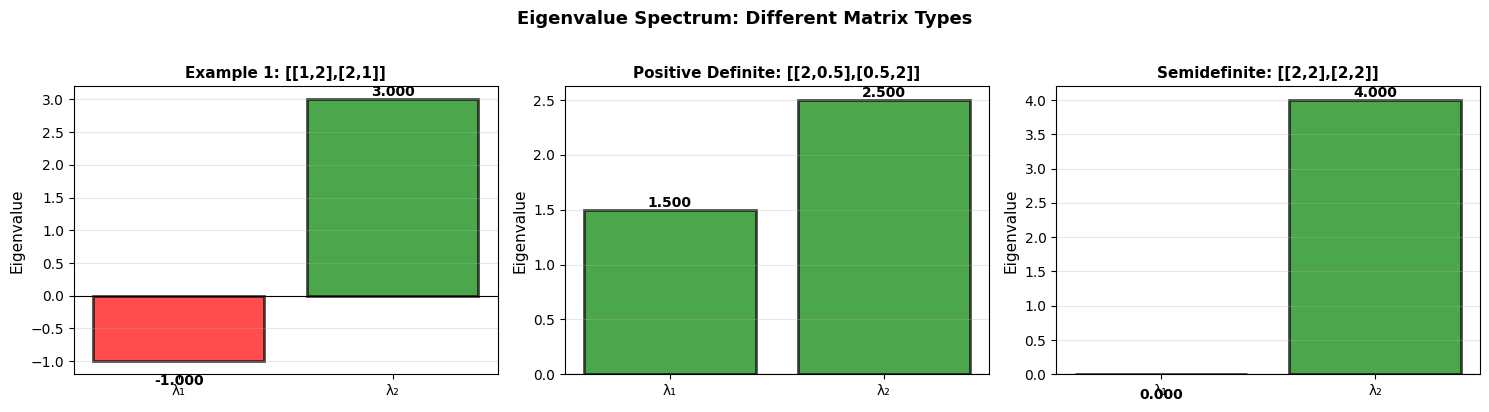

Visualization: Eigenvalue Spectrum
- Example 1: Mixed positive/negative eigenvalues
- Positive Definite: All eigenvalues > 0
- Positive Semidefinite: All eigenvalues ≥ 0 (one is essentially 0)


In [64]:
# Visualization: Eigenvalue Spectrum Across Different Matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Define matrices for comparison
M_pd = torch.tensor([[2.0, 0.5], [0.5, 2.0]], dtype=torch.float32)
M_psd = torch.tensor([[2.0, 2.0], [2.0, 2.0]], dtype=torch.float32)

matrices_dict = {
    'Example 1': (M, torch.linalg.eigh(M)[0], 'Example 1: [[1,2],[2,1]]'),
    'Positive Definite': (M_pd, torch.linalg.eigh(M_pd)[0], 'Positive Definite: [[2,0.5],[0.5,2]]'),
    'Positive Semidefinite': (M_psd, torch.linalg.eigh(M_psd)[0], 'Semidefinite: [[2,2],[2,2]]'),
}

for ax, (mat_name, (matrix, eigs, title)) in zip(axes, matrices_dict.items()):
    eigs_np = eigs.numpy()
    colors = ['green' if e > 0 else 'red' for e in eigs_np]
    
    bars = ax.bar(range(len(eigs_np)), eigs_np, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
    ax.axhline(y=0, color='k', linestyle='-', linewidth=0.8)
    
    ax.set_xticks(range(len(eigs_np)))
    ax.set_xticklabels([f'λ₁', f'λ₂'])
    ax.set_ylabel('Eigenvalue', fontsize=11)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for bar, val in zip(bars, eigs_np):
        height = bar.get_height()
        y_pos = height if height > 0 else height - 0.2
        ax.text(bar.get_x() + bar.get_width()/2., y_pos, f'{val:.3f}',
                ha='center', va='bottom' if height > 0 else 'top', fontweight='bold', fontsize=10)

plt.suptitle('Eigenvalue Spectrum: Different Matrix Types', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Visualization: Eigenvalue Spectrum")
print("- Example 1: Mixed positive/negative eigenvalues")
print("- Positive Definite: All eigenvalues > 0")  
print("- Positive Semidefinite: All eigenvalues ≥ 0 (one is essentially 0)")

## Positive Definite and Positive Semidefinite Matrices

In [65]:
# Positive Definite Matrix
# Definition: Symmetric matrix where x^T @ M @ x > 0 for any non-zero vector x
# Property: All eigenvalues are positive

print("Positive Definite Matrix")
print("="*50)

M_pd = torch.tensor([[2.0, 0.5],
                      [0.5, 2.0]], dtype=torch.float32)

print(f"\nMatrix M (positive definite):")
print(M_pd)

eigenvalues_pd, _ = torch.linalg.eigh(M_pd)
print(f"\nEigenvalues: {eigenvalues_pd.numpy()}")
print(f"All eigenvalues positive: {torch.all(eigenvalues_pd > 0)}")

# Test quadratic form x^T @ M @ x for random vectors
print(f"\nQuadratic form test (x^T @ M @ x for random vectors):")
for i in range(3):
    x = torch.randn(2)
    quad_form = x @ M_pd @ x
    print(f"Vector {i+1}: x^T @ M @ x = {quad_form:.4f} (positive)")

Positive Definite Matrix

Matrix M (positive definite):
tensor([[2.0000, 0.5000],
        [0.5000, 2.0000]])

Eigenvalues: [1.5 2.5]
All eigenvalues positive: True

Quadratic form test (x^T @ M @ x for random vectors):
Vector 1: x^T @ M @ x = 16.0461 (positive)
Vector 2: x^T @ M @ x = 0.6593 (positive)
Vector 3: x^T @ M @ x = 17.6540 (positive)


In [66]:
# Positive Semidefinite Matrix
# Definition: Symmetric matrix where x^T @ M @ x ≥ 0 for any vector x
# Property: All eigenvalues are non-negative (some can be zero)

print("Positive Semidefinite Matrix")
print("="*50)

# Create a rank-deficient matrix
M_psd = torch.tensor([[2.0, 2.0],
                       [2.0, 2.0]], dtype=torch.float32)

print(f"\nMatrix M (positive semidefinite):")
print(M_psd)

eigenvalues_psd, _ = torch.linalg.eigh(M_psd)
print(f"\nEigenvalues: {eigenvalues_psd.numpy()}")
print(f"All eigenvalues non-negative: {torch.all(eigenvalues_psd >= 0)}")
print(f"Has zero eigenvalue: {torch.any(eigenvalues_psd == 0)}")

# Test quadratic form x^T @ M @ x for random vectors
print(f"\nQuadratic form test (x^T @ M @ x for random vectors):")
for i in range(3):
    x = torch.randn(2)
    quad_form = x @ M_psd @ x
    print(f"Vector {i+1}: x^T @ M @ x = {quad_form:.4f} (non-negative)")

Positive Semidefinite Matrix

Matrix M (positive semidefinite):
tensor([[2., 2.],
        [2., 2.]])

Eigenvalues: [0. 4.]
All eigenvalues non-negative: True
Has zero eigenvalue: True

Quadratic form test (x^T @ M @ x for random vectors):
Vector 1: x^T @ M @ x = 6.3153 (non-negative)
Vector 2: x^T @ M @ x = 0.1213 (non-negative)
Vector 3: x^T @ M @ x = 0.2057 (non-negative)


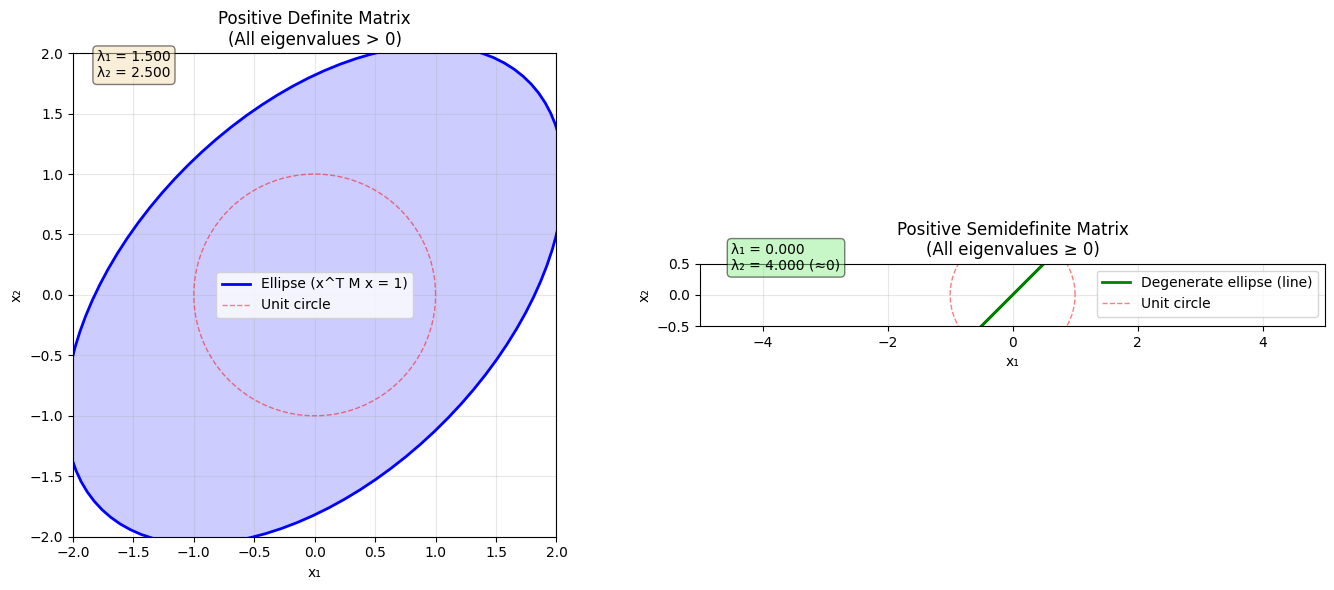

Visualization: Positive Definite vs Semidefinite
- Positive Definite: Forms a proper ellipse (all eigenvalues > 0)
- Positive Semidefinite: Degenerates to a line (has eigenvalue = 0)


In [67]:

# Visualization: Positive Definite vs Positive Semidefinite Matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Generate test vectors in circle
angles = np.linspace(0, 2*np.pi, 100)
circle_vectors = np.column_stack([np.cos(angles), np.sin(angles)])

# Positive Definite
ax = axes[0]
M_pd_np = M_pd.numpy()
quad_values_pd = []
for v in circle_vectors:
    quad = v @ M_pd_np @ v
    quad_values_pd.append(quad)

ellipse_pd = (M_pd_np @ circle_vectors.T).T
ax.plot(ellipse_pd[:, 0], ellipse_pd[:, 1], 'b-', linewidth=2, label='Ellipse (x^T M x = 1)')
ax.fill(ellipse_pd[:, 0], ellipse_pd[:, 1], alpha=0.2, color='blue')
ax.plot(circle_vectors[:, 0], circle_vectors[:, 1], 'r--', alpha=0.5, linewidth=1, label='Unit circle')

ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.set_xlabel('x₁')
ax.set_ylabel('x₂')
ax.set_title(f'Positive Definite Matrix\n(All eigenvalues > 0)')
ax.legend()

# Add eigenvalue info
eigs_pd = torch.linalg.eigh(M_pd)[0].numpy()
ax.text(-1.8, 1.8, f'λ₁ = {eigs_pd[0]:.3f}\nλ₂ = {eigs_pd[1]:.3f}', 
        fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Positive Semidefinite
ax = axes[1]
M_psd_np = M_psd.numpy()
ellipse_psd = (M_psd_np @ circle_vectors.T).T
ax.plot(ellipse_psd[:, 0], ellipse_psd[:, 1], 'g-', linewidth=2, label='Degenerate ellipse (line)')
ax.fill(ellipse_psd[:, 0], ellipse_psd[:, 1], alpha=0.2, color='green')
ax.plot(circle_vectors[:, 0], circle_vectors[:, 1], 'r--', alpha=0.5, linewidth=1, label='Unit circle')

ax.set_xlim(-5, 5)
ax.set_ylim(-0.5, 0.5)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.set_xlabel('x₁')
ax.set_ylabel('x₂')
ax.set_title(f'Positive Semidefinite Matrix\n(All eigenvalues ≥ 0)')
ax.legend()

# Add eigenvalue info
eigs_psd = torch.linalg.eigh(M_psd)[0].numpy()
ax.text(-4.5, 0.4, f'λ₁ = {eigs_psd[0]:.3f}\nλ₂ = {eigs_psd[1]:.3f} (≈0)', 
        fontsize=10, bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

plt.tight_layout()
plt.show()

print("Visualization: Positive Definite vs Semidefinite")
print("- Positive Definite: Forms a proper ellipse (all eigenvalues > 0)")
print("- Positive Semidefinite: Degenerates to a line (has eigenvalue = 0)")

## Eigenvalue Decomposition

In [68]:
# Eigenvalue Decomposition: M = Q @ Λ @ Q^T
# where Q is the matrix of eigenvectors
# and Λ is the diagonal matrix of eigenvalues

print("Eigenvalue Decomposition: M = Q @ Λ @ Q^T")
print("="*50)

M = torch.tensor([[1.0, 2.0],
                   [2.0, 1.0]], dtype=torch.float32)

eigenvalues, Q = torch.linalg.eigh(M)

# Create diagonal matrix Λ
Lambda = torch.diag(eigenvalues)

print(f"\nOriginal Matrix M:")
print(M)

print(f"\nEigenvector Matrix Q:")
print(Q)

print(f"\nDiagonal Eigenvalue Matrix Λ:")
print(Lambda)

# Reconstruct M
M_reconstructed = Q @ Lambda @ Q.T

print(f"\nReconstructed M = Q @ Λ @ Q^T:")
print(M_reconstructed)

print(f"\nReconstruction matches original: {torch.allclose(M, M_reconstructed)}")

Eigenvalue Decomposition: M = Q @ Λ @ Q^T

Original Matrix M:
tensor([[1., 2.],
        [2., 1.]])

Eigenvector Matrix Q:
tensor([[-0.7071,  0.7071],
        [ 0.7071,  0.7071]])

Diagonal Eigenvalue Matrix Λ:
tensor([[-1.,  0.],
        [ 0.,  3.]])

Reconstructed M = Q @ Λ @ Q^T:
tensor([[1.0000, 2.0000],
        [2.0000, 1.0000]])

Reconstruction matches original: True


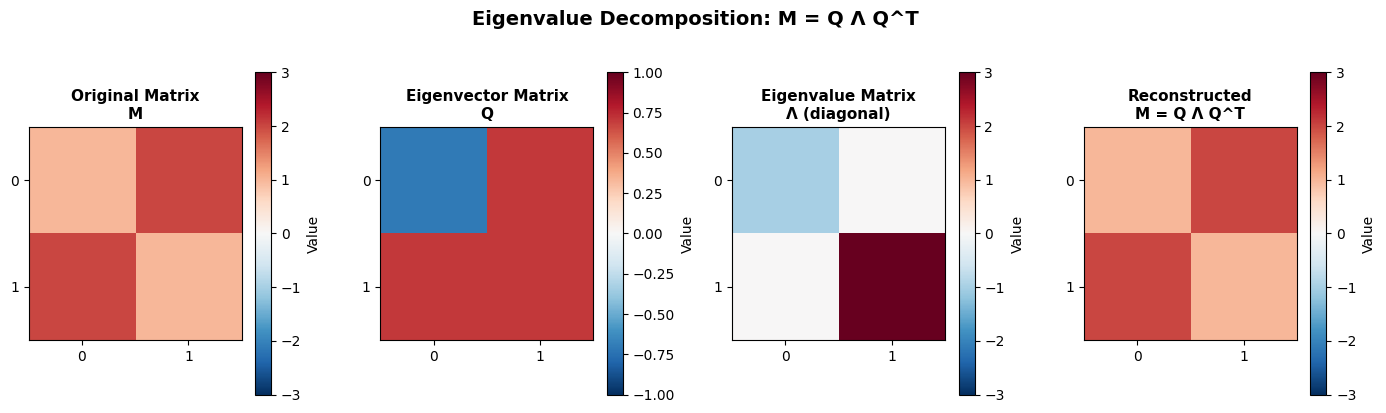


Visualization: Eigenvalue Decomposition
- Matrix M is decomposed into eigenvectors (Q) and eigenvalues (Λ)
- The decomposition perfectly reconstructs the original matrix


In [69]:

# Visualization: Eigenvalue Decomposition M = Q Λ Q^T
fig = plt.figure(figsize=(14, 4))

# Left: Original matrix M visualization
ax1 = fig.add_subplot(141)
im1 = ax1.imshow(M.numpy(), cmap='RdBu_r', vmin=-3, vmax=3)
ax1.set_title('Original Matrix\nM', fontsize=11, fontweight='bold')
ax1.set_xticks([0, 1])
ax1.set_yticks([0, 1])
plt.colorbar(im1, ax=ax1, label='Value')

# Second: Eigenvector matrix Q
ax2 = fig.add_subplot(142)
im2 = ax2.imshow(eigenvectors.numpy(), cmap='RdBu_r', vmin=-1, vmax=1)
ax2.set_title('Eigenvector Matrix\nQ', fontsize=11, fontweight='bold')
ax2.set_xticks([0, 1])
ax2.set_yticks([0, 1])
plt.colorbar(im2, ax=ax2, label='Value')

# Third: Diagonal eigenvalue matrix Lambda
ax3 = fig.add_subplot(143)
Lambda_mat = torch.diag(eigenvalues).numpy()
im3 = ax3.imshow(Lambda_mat, cmap='RdBu_r', vmin=-3, vmax=3)
ax3.set_title('Eigenvalue Matrix\nΛ (diagonal)', fontsize=11, fontweight='bold')
ax3.set_xticks([0, 1])
ax3.set_yticks([0, 1])
plt.colorbar(im3, ax=ax3, label='Value')

# Fourth: Reconstructed matrix M = Q Λ Q^T
ax4 = fig.add_subplot(144)
M_recon = eigenvectors @ torch.diag(eigenvalues) @ eigenvectors.T
im4 = ax4.imshow(M_recon.numpy(), cmap='RdBu_r', vmin=-3, vmax=3)
ax4.set_title('Reconstructed\nM = Q Λ Q^T', fontsize=11, fontweight='bold')
ax4.set_xticks([0, 1])
ax4.set_yticks([0, 1])
plt.colorbar(im4, ax=ax4, label='Value')

plt.suptitle('Eigenvalue Decomposition: M = Q Λ Q^T', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\nVisualization: Eigenvalue Decomposition")
print("- Matrix M is decomposed into eigenvectors (Q) and eigenvalues (Λ)")
print("- The decomposition perfectly reconstructs the original matrix")

## Example: 3×3 Matrix

In [70]:
# 3x3 symmetric matrix
M_3x3 = torch.tensor([[6.0, 0.0, 0.0],
                       [0.0, 3.0, 1.0],
                       [0.0, 1.0, 3.0]], dtype=torch.float32)

print("3×3 Symmetric Matrix M:")
print(M_3x3)

eigenvalues_3, eigenvectors_3 = torch.linalg.eigh(M_3x3)

print(f"\nEigenvalues: {eigenvalues_3.numpy()}")
print(f"\nEigenvectors:")
print(eigenvectors_3)

# Verify properties
trace_3 = torch.trace(M_3x3)
sum_eigs_3 = torch.sum(eigenvalues_3)
print(f"\nTrace(M) = {trace_3:.4f}")
print(f"Sum of eigenvalues = {sum_eigs_3:.4f}")

det_3 = torch.det(M_3x3)
prod_eigs_3 = torch.prod(eigenvalues_3)
print(f"\ndet(M) = {det_3:.4f}")
print(f"Product of eigenvalues = {prod_eigs_3:.4f}")

3×3 Symmetric Matrix M:
tensor([[6., 0., 0.],
        [0., 3., 1.],
        [0., 1., 3.]])

Eigenvalues: [2. 4. 6.]

Eigenvectors:
tensor([[ 0.0000,  0.0000,  1.0000],
        [-0.7071,  0.7071,  0.0000],
        [ 0.7071,  0.7071,  0.0000]])

Trace(M) = 12.0000
Sum of eigenvalues = 12.0000

det(M) = 48.0000
Product of eigenvalues = 48.0000


## Applications: Principal Component Analysis (PCA)

In [71]:
# PCA uses eigenvalue decomposition of the covariance matrix
# Eigenvectors are the principal components
# Eigenvalues indicate the variance along each principal component

print("PCA: Using Eigen Analysis")
print("="*50)

# Create sample data
torch.manual_seed(42)
n_samples = 100
X = torch.randn(n_samples, 2)

# Add correlation
X[:, 1] = X[:, 0] + torch.randn(n_samples) * 0.5

print(f"\nData shape: {X.shape}")

# Center the data
X_centered = X - X.mean(dim=0)

# Compute covariance matrix
Cov = (X_centered.T @ X_centered) / (n_samples - 1)

print(f"\nCovariance Matrix:")
print(Cov)

# Compute eigenvalues and eigenvectors
eigenvalues_cov, eigenvectors_cov = torch.linalg.eigh(Cov)

# Sort in descending order
idx = torch.argsort(eigenvalues_cov, descending=True)
eigenvalues_cov = eigenvalues_cov[idx]
eigenvectors_cov = eigenvectors_cov[:, idx]

print(f"\nEigenvalues (variances): {eigenvalues_cov.numpy()}")
print(f"\nEigenvectors (principal components):")
print(eigenvectors_cov)

# Project data onto principal components
X_pca = X_centered @ eigenvectors_cov

print(f"\nPCA-transformed data shape: {X_pca.shape}")
print(f"First 5 samples:")
print(X_pca[:5])

PCA: Using Eigen Analysis

Data shape: torch.Size([100, 2])

Covariance Matrix:
tensor([[1.0652, 1.1162],
        [1.1162, 1.3747]])

Eigenvalues (variances): [2.3468442  0.09307867]

Eigenvectors (principal components):
tensor([[ 0.6568, -0.7541],
        [ 0.7541,  0.6568]])

PCA-transformed data shape: torch.Size([100, 2])
First 5 samples:
tensor([[ 3.3541,  0.1628],
        [ 1.5988, -0.0051],
        [ 1.5288,  0.2288],
        [-0.0507, -0.1902],
        [-0.7807,  0.1144]])


/tmp/ipykernel_360657/1488493832.py:21: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  scale*np.sqrt(eig_val)*eig_vec[0], scale*np.sqrt(eig_val)*eig_vec[1],


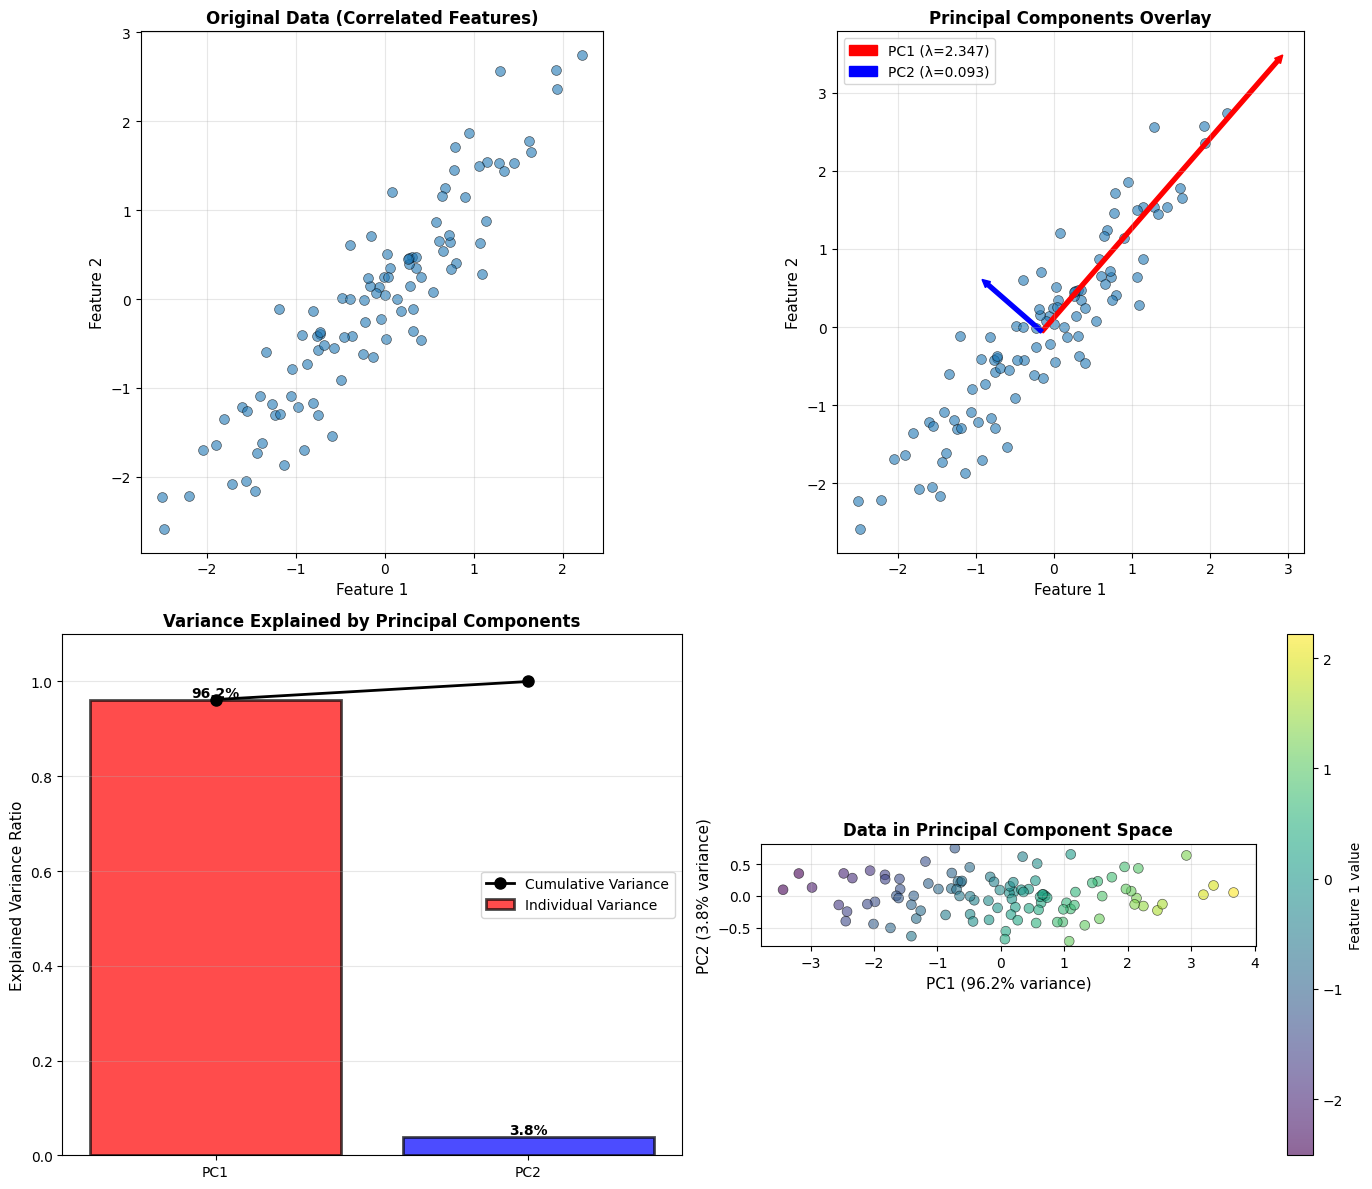

Visualization: Principal Component Analysis
- PC1 explains 96.2% of variance
- PC2 explains 3.8% of variance
- Total variance: 100.0%

Key insight: PCA rotates data to align with directions of maximum variance


In [72]:

# Visualization: PCA - Data in Original vs Principal Component Space
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Plot 1: Original data
ax = axes[0, 0]
ax.scatter(X[:, 0], X[:, 1], alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
ax.set_xlabel('Feature 1', fontsize=11)
ax.set_ylabel('Feature 2', fontsize=11)
ax.set_title('Original Data (Correlated Features)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

# Plot 2: Data with principal components
ax = axes[0, 1]
ax.scatter(X[:, 0], X[:, 1], alpha=0.6, s=50, edgecolors='black', linewidth=0.5)

# Draw principal components (scaled by sqrt of eigenvalues)
scale = 3
for i, (eig_val, eig_vec) in enumerate(zip(eigenvalues_cov, eigenvectors_cov.T)):
    ax.arrow(X[:, 0].mean(), X[:, 1].mean(), 
             scale*np.sqrt(eig_val)*eig_vec[0], scale*np.sqrt(eig_val)*eig_vec[1],
             head_width=0.1, head_length=0.1, fc=['red', 'blue'][i], ec=['red', 'blue'][i], 
             width=0.05, label=f'PC{i+1} (λ={eig_val:.3f})')

ax.set_xlabel('Feature 1', fontsize=11)
ax.set_ylabel('Feature 2', fontsize=11)
ax.set_title('Principal Components Overlay', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_aspect('equal')

# Plot 3: Variance explained
ax = axes[1, 0]
variance_explained = eigenvalues_cov / eigenvalues_cov.sum()
cumulative_variance = torch.cumsum(variance_explained, dim=0)

bars = ax.bar(range(len(eigenvalues_cov)), variance_explained.numpy(), 
              alpha=0.7, label='Individual Variance', color=['red', 'blue'], edgecolor='black', linewidth=2)
ax.plot(range(len(eigenvalues_cov)), cumulative_variance.numpy(), 'ko-', 
        linewidth=2, markersize=8, label='Cumulative Variance')

ax.set_xticks(range(len(eigenvalues_cov)))
ax.set_xticklabels(['PC1', 'PC2'])
ax.set_ylabel('Explained Variance Ratio', fontsize=11)
ax.set_title('Variance Explained by Principal Components', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.legend()
ax.set_ylim([0, 1.1])

# Add percentage labels
for i, (bar, val) in enumerate(zip(bars, variance_explained.numpy())):
    ax.text(bar.get_x() + bar.get_width()/2., val, f'{val*100:.1f}%', 
            ha='center', va='bottom', fontweight='bold')

# Plot 4: Data in PCA space
ax = axes[1, 1]
colors = plt.cm.viridis(np.linspace(0, 1, len(X)))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6, s=50, c=X[:, 0].numpy(), 
                     cmap='viridis', edgecolors='black', linewidth=0.5)
ax.set_xlabel(f'PC1 ({variance_explained[0]*100:.1f}% variance)', fontsize=11)
ax.set_ylabel(f'PC2 ({variance_explained[1]*100:.1f}% variance)', fontsize=11)
ax.set_title('Data in Principal Component Space', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
plt.colorbar(scatter, ax=ax, label='Feature 1 value')

plt.tight_layout()
plt.show()

print("Visualization: Principal Component Analysis")
print(f"- PC1 explains {variance_explained[0]*100:.1f}% of variance")
print(f"- PC2 explains {variance_explained[1]*100:.1f}% of variance")
print(f"- Total variance: {cumulative_variance[-1]*100:.1f}%")
print("\nKey insight: PCA rotates data to align with directions of maximum variance")

## Summary: Key Concepts

| Concept | Definition | Key Property |
|---------|-----------|---------------|
| **Eigenvalue** | Scalar λ satisfying Mq = λq | Indicates scaling factor |
| **Eigenvector** | Non-zero vector q satisfying Mq = λq | Does not change direction |
| **Characteristic Equation** | (M - λI)q = 0 | Defines eigenvalues |
| **Orthonormal Eigenvectors** | Eigenvectors with unit norm and perpendicular to each other | Simplifies computations |
| **Trace Property** | Tr(M) = Σ λᵢ | Sum of diagonal elements = sum of eigenvalues |
| **Determinant Property** | det(M) = ∏ λᵢ | Product of eigenvalues |
| **Positive Definite** | All eigenvalues > 0 | x^T Mx > 0 for all x ≠ 0 |
| **Positive Semidefinite** | All eigenvalues ≥ 0 | x^T Mx ≥ 0 for all x |
| **Eigenvalue Decomposition** | M = Q Λ Q^T | Matrix expressed in basis of eigenvectors |